In [52]:
# =========================================
# 1️⃣ INSTALL PACKAGES (run once)
# =========================================
!pip install linearmodels openpyxl --quiet


In [43]:
    # =========================================
    # 2️⃣ IMPORT LIBRARIES
    # =========================================
    import pandas as pd
    from linearmodels.panel import PanelOLS
    # Remember: Ensure Google Drive is mounted if you're loading files from it.


In [44]:
# =========================================
# 3️⃣ LOAD DATA
# =========================================
df = pd.read_excel('/content/drive/MyDrive/PANEL MODELING    DISERTATION /PANEL_DATA_US.xlsx')

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# Clean column names (important for safety)
df.columns = df.columns.str.strip()


In [47]:
# =========================================
# 4️⃣ BASIC CHECKS (VERY IMPORTANT)
# =========================================
print(df.head())
print(df.info())
print(df.isna().sum())  # check missing values


     STATE  YEAR  PCE (mil.$)  Real PI (mil.2017$)  RPPs (index)  \
0  Alabama  2008     130009.5             199198.2        88.901   
1  Alabama  2009     128265.5             199669.6        87.786   
2  Alabama  2010     132314.4             199704.6        89.783   
3  Alabama  2011     136772.4             201259.2        90.011   
4  Alabama  2012     139950.6             201300.9        90.559   

   Real GDP (mil.2017$)  Employment (jobs)  Personal Income (mil.$)  \
0              200967.4            2582600                 157780.3   
1              194192.1            2479511                 155666.9   
2              199455.0            2460305                 162068.8   
3              201372.8            2497974                 167882.2   
4              203675.5            2503656                 172101.5   

   PI Per Capita ($)  Real PI Per Capita (2017$)  
0              33441                       42219  
1              32717                       41966  
2          

In [10]:
# =========================================
# 5️⃣ SET PANEL STRUCTURE
# =========================================
df = df.set_index(["STATE", "YEAR"])


In [11]:
# =========================================
# 6️⃣ MAIN MODEL (FIXED EFFECTS)
# =========================================
model = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + Q("Real GDP (mil.2017$)") + Q("Employment (jobs)") + Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results = model.fit(cov_type='clustered', cluster_entity=True)

print("\n=== MAIN MODEL RESULTS ===")
print(results)



=== MAIN MODEL RESULTS ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9662
Estimator:                   PanelOLS   R-squared (Between):              0.1423
No. Observations:                 884   R-squared (Within):               0.9667
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.1818
Time:                        00:26:59   Log-likelihood                -1.119e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5807.5
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(4,812)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):           7.03e+04


In [12]:
# =========================================
# 7️⃣ ROBUSTNESS CHECK (REMOVE GDP)
# =========================================
model2 = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results2 = model2.fit(cov_type='clustered', cluster_entity=True)

print("\n=== ROBUSTNESS MODEL (NO GDP) ===")
print(results2)


=== ROBUSTNESS MODEL (NO GDP) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9105
Estimator:                   PanelOLS   R-squared (Between):              0.6042
No. Observations:                 884   R-squared (Within):               0.9106
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.6189
Time:                        00:26:59   Log-likelihood                -1.162e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4139.9
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(2,814)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):          3.1

In [13]:
# =========================================
# 8️⃣ OPTIONAL: CORRELATION CHECK
# =========================================
print("\n=== CORRELATION MATRIX ===")
print(df.reset_index()[[
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)",
    "RPPs (index)"
]].corr())



=== CORRELATION MATRIX ===
                      PCE (mil.$)  Real PI (mil.2017$)  Real GDP (mil.2017$)  \
PCE (mil.$)              1.000000             0.994327              0.992885   
Real PI (mil.2017$)      0.994327             1.000000              0.999082   
Real GDP (mil.2017$)     0.992885             0.999082              1.000000   
Employment (jobs)        0.987661             0.997530              0.998569   
RPPs (index)             0.107857             0.102628              0.116467   

                      Employment (jobs)  RPPs (index)  
PCE (mil.$)                    0.987661      0.107857  
Real PI (mil.2017$)            0.997530      0.102628  
Real GDP (mil.2017$)           0.998569      0.116467  
Employment (jobs)              1.000000      0.099206  
RPPs (index)                   0.099206      1.000000  


In [48]:
# =========================================
# 9️⃣ SAVE RESULTS (OPTIONAL)
# =========================================
with open("model_results.txt", "w") as f:
    f.write(str(results))

print("\nResults saved!")


Results saved!


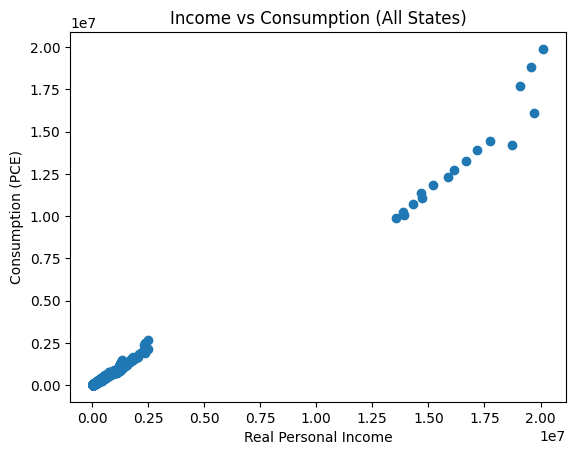

In [49]:
import matplotlib.pyplot as plt

# Reset index for plotting
df_plot = df.reset_index()

plt.scatter(df_plot["Real PI (mil.2017$)"], df_plot["PCE (mil.$)"])
plt.xlabel("Real Personal Income")
plt.ylabel("Consumption (PCE)")
plt.title("Income vs Consumption (All States)")
plt.show()

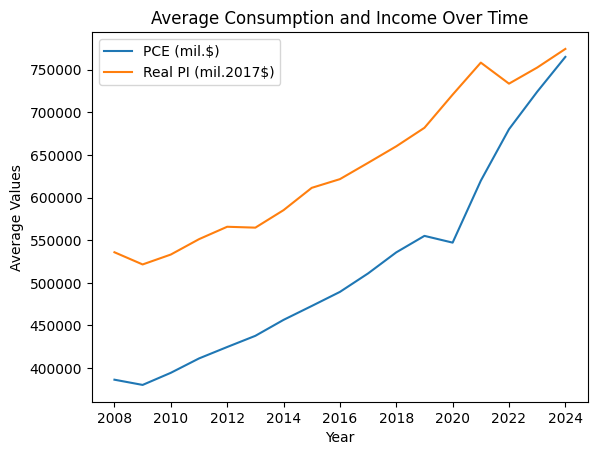

In [50]:
df_time = df_plot.groupby("YEAR")[["PCE (mil.$)", "Real PI (mil.2017$)"]].mean()

df_time.plot()
plt.title("Average Consumption and Income Over Time")
plt.xlabel("Year")
plt.ylabel("Average Values")
plt.show()

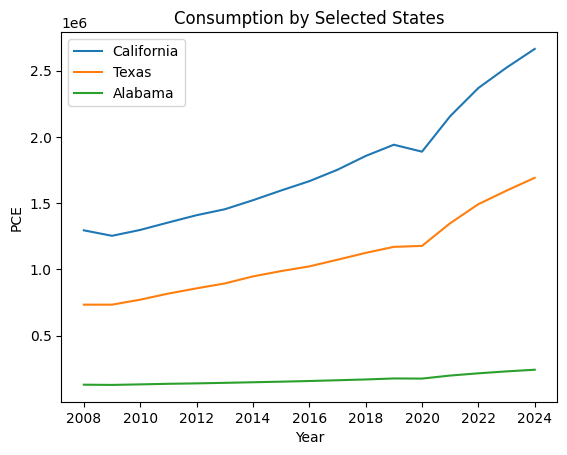

In [17]:
states = ["California", "Texas", "Alabama"]

for state in states:
    subset = df_plot[df_plot["STATE"] == state]
    plt.plot(subset["YEAR"], subset["PCE (mil.$)"], label=state)

plt.title("Consumption by Selected States")
plt.xlabel("Year")
plt.ylabel("PCE")
plt.legend()
plt.show()

In [18]:
import numpy as np

df_log = df.copy()

df_log["log_PCE"] = np.log(df_log["PCE (mil.$)"])
df_log["log_RPI"] = np.log(df_log["Real PI (mil.2017$)"])

model_log = PanelOLS.from_formula(
    'log_PCE ~ log_RPI + EntityEffects + TimeEffects',
    data=df_log
)

results_log = model_log.fit(cov_type='clustered', cluster_entity=True)
print(results_log)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_PCE   R-squared:                        0.7388
Estimator:                   PanelOLS   R-squared (Between):              0.9100
No. Observations:                 884   R-squared (Within):               0.6465
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.9099
Time:                        00:27:00   Log-likelihood                    2275.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2304.9
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(1,815)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):             376.18
                            

In [19]:
#complete analysis

In [20]:
# DESCRIPTIVE STATISTICS
# =========================================
desc = df.reset_index()[[
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "RPPs (index)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)"
]].describe()

print("\n=== DESCRIPTIVE STATISTICS ===")
print(desc)

# Optional: save descriptive stats
desc.to_excel("descriptive_statistics.xlsx")


=== DESCRIPTIVE STATISTICS ===
        PCE (mil.$)  Real PI (mil.2017$)  RPPs (index)  Real GDP (mil.2017$)  \
count  8.840000e+02         8.840000e+02    884.000000          8.840000e+02   
mean   5.171627e+05         6.360375e+05     97.551459          7.421353e+05   
std    1.887839e+06         2.279228e+06      6.878319          2.666236e+06   
min    1.865320e+04         2.799780e+04     85.018000          2.956570e+04   
25%    6.613625e+04         8.106170e+04     91.873750          9.183402e+04   
50%    1.675598e+05         2.200996e+05     97.053500          2.324788e+05   
75%    3.393250e+05         4.142877e+05    102.363750          4.882802e+05   
max    1.989601e+07         2.013294e+07    114.242000          2.335844e+07   

       Employment (jobs)  
count       8.840000e+02  
mean        7.408213e+06  
std         2.635708e+07  
min         3.850750e+05  
25%         9.205592e+05  
50%         2.533227e+06  
75%         4.871016e+06  
max         2.181812e+08  


In [21]:
# CORRELATION MATRIX
# =========================================
corr = df.reset_index()[[
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)",
    "RPPs (index)"
]].corr()

print("\n=== CORRELATION MATRIX ===")
print(corr)

corr.to_excel("correlation_matrix.xlsx")



=== CORRELATION MATRIX ===
                      PCE (mil.$)  Real PI (mil.2017$)  Real GDP (mil.2017$)  \
PCE (mil.$)              1.000000             0.994327              0.992885   
Real PI (mil.2017$)      0.994327             1.000000              0.999082   
Real GDP (mil.2017$)     0.992885             0.999082              1.000000   
Employment (jobs)        0.987661             0.997530              0.998569   
RPPs (index)             0.107857             0.102628              0.116467   

                      Employment (jobs)  RPPs (index)  
PCE (mil.$)                    0.987661      0.107857  
Real PI (mil.2017$)            0.997530      0.102628  
Real GDP (mil.2017$)           0.998569      0.116467  
Employment (jobs)              1.000000      0.099206  
RPPs (index)                   0.099206      1.000000  


In [22]:
# MAIN MODEL (full specification)
# =========================================
model_main = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + Q("Real GDP (mil.2017$)") + Q("Employment (jobs)") + Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results_main = model_main.fit(cov_type="clustered", cluster_entity=True)

print("\n=== MAIN MODEL ===")
print(results_main)


=== MAIN MODEL ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9662
Estimator:                   PanelOLS   R-squared (Between):              0.1423
No. Observations:                 884   R-squared (Within):               0.9667
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.1818
Time:                        00:27:00   Log-likelihood                -1.119e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5807.5
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(4,812)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):           7.03e+04
        

In [23]:
# =========================================
# REFINED MODEL (preferred levels model)
# =========================================
model_refined = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results_refined = model_refined.fit(cov_type="clustered", cluster_entity=True)

print("\n=== REFINED MODEL ===")
print(results_refined)


=== REFINED MODEL ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9105
Estimator:                   PanelOLS   R-squared (Between):              0.6042
No. Observations:                 884   R-squared (Within):               0.9106
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.6189
Time:                        00:27:00   Log-likelihood                -1.162e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4139.9
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(2,814)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):          3.173e+05
     

In [24]:
#  LOG MODEL (preferred final model)
# =========================================
df_log = df.copy()
df_log["log_PCE"] = np.log(df_log['PCE (mil.$)'])
df_log["log_RPI"] = np.log(df_log['Real PI (mil.2017$)'])

model_log = PanelOLS.from_formula(
    'log_PCE ~ log_RPI + EntityEffects + TimeEffects',
    data=df_log
)

results_log = model_log.fit(cov_type="clustered", cluster_entity=True)

print("\n=== LOG MODEL ===")
print(results_log)


=== LOG MODEL ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                log_PCE   R-squared:                        0.7388
Estimator:                   PanelOLS   R-squared (Between):              0.9100
No. Observations:                 884   R-squared (Within):               0.6465
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.9099
Time:                        00:27:01   Log-likelihood                    2275.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2304.9
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(1,815)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):             376.18
         

In [25]:
# DYNAMIC MODEL (advanced extension)
# =========================================
df_dyn = df.copy()
df_dyn["lag_PCE"] = df_dyn.groupby(level=0)['PCE (mil.$)'].shift(1)
df_dyn = df_dyn.dropna()

model_dyn = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ lag_PCE + Q("Real PI (mil.2017$)") + EntityEffects + TimeEffects',
    data=df_dyn
)

results_dyn = model_dyn.fit(cov_type="clustered", cluster_entity=True)

print("\n=== DYNAMIC MODEL ===")
print(results_dyn)


=== DYNAMIC MODEL ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9821
Estimator:                   PanelOLS   R-squared (Between):              0.9681
No. Observations:                 832   R-squared (Within):               0.9821
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.9688
Time:                        00:27:01   Log-likelihood                -1.026e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   2.091e+04
Entities:                          52   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(2,763)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):          1.296e+07
     

In [26]:
#  PER CAPITA ROBUSTNESS MODEL
# =========================================
df_pc = df.copy()

# Approximation using employment as scale if population not available
# If you later get population, replace Employment with Population
df_pc["PCE_per_worker"] = df_pc['PCE (mil.$)'] / df_pc['Employment (jobs)']
df_pc["RPI_per_worker"] = df_pc['Real PI (mil.2017$)'] / df_pc['Employment (jobs)']

# Drop invalid values just in case
df_pc = df_pc.replace([np.inf, -np.inf], np.nan).dropna()

df_pc["log_PCE_per_worker"] = np.log(df_pc["PCE_per_worker"])
df_pc["log_RPI_per_worker"] = np.log(df_pc["RPI_per_worker"])

model_pc = PanelOLS.from_formula(
    'log_PCE_per_worker ~ log_RPI_per_worker + EntityEffects + TimeEffects',
    data=df_pc
)

results_pc = model_pc.fit(cov_type="clustered", cluster_entity=True)

print("\n=== PER CAPITA / PER WORKER ROBUSTNESS MODEL ===")
print(results_pc)


=== PER CAPITA / PER WORKER ROBUSTNESS MODEL ===
                          PanelOLS Estimation Summary                           
Dep. Variable:     log_PCE_per_worker   R-squared:                        0.2238
Estimator:                   PanelOLS   R-squared (Between):              0.4990
No. Observations:                 884   R-squared (Within):               0.2613
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.4983
Time:                        00:27:01   Log-likelihood                    2438.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      234.93
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(1,815)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust

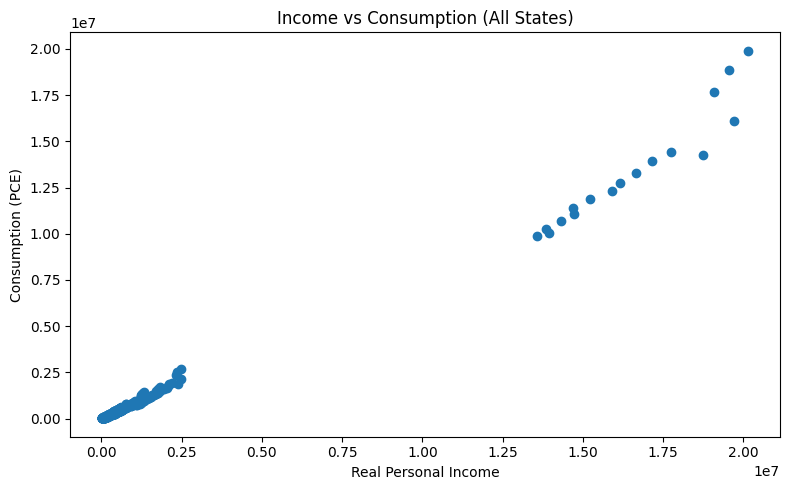

In [54]:
# 9. PLOTS
# =========================================
df_plot = df.reset_index()

# 9.1 Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df_plot["Real PI (mil.2017$)"], df_plot["PCE (mil.$)"])
plt.xlabel("Real Personal Income")
plt.ylabel("Consumption (PCE)")
plt.title("Income vs Consumption (All States)")
plt.tight_layout()
plt.savefig("scatter_income_consumption.png", dpi=300)
plt.show()




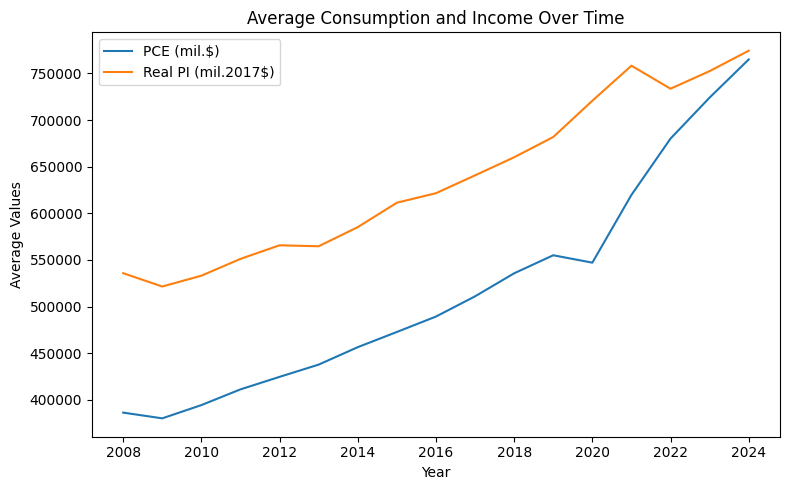

In [28]:
# 9.2 Average time trend
df_time = df_plot.groupby("YEAR")[["PCE (mil.$)", "Real PI (mil.2017$)"]].mean()

plt.figure(figsize=(8,5))
plt.plot(df_time.index, df_time["PCE (mil.$)"], label="PCE (mil.$)")
plt.plot(df_time.index, df_time["Real PI (mil.2017$)"], label="Real PI (mil.2017$)")
plt.xlabel("Year")
plt.ylabel("Average Values")
plt.title("Average Consumption and Income Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("time_trend_income_consumption.png", dpi=300)
plt.show()



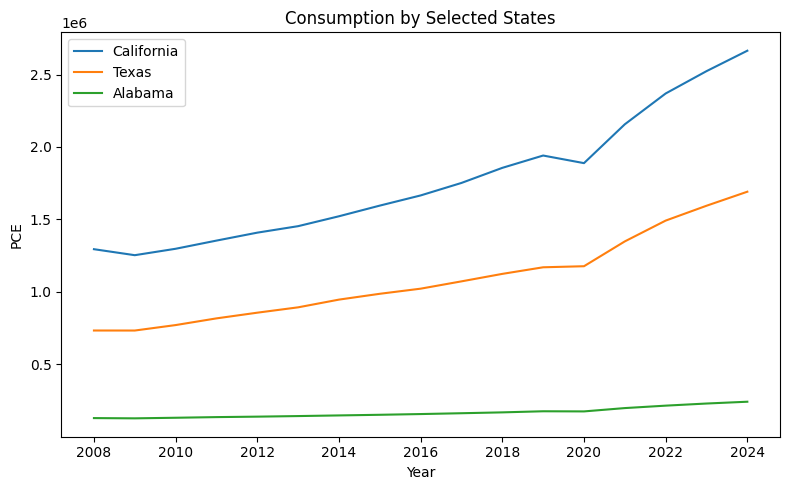

In [29]:
 #9.3 Selected states
states = ["California", "Texas", "Alabama"]

plt.figure(figsize=(8,5))
for state in states:
    subset = df_plot[df_plot["STATE"] == state]
    plt.plot(subset["YEAR"], subset["PCE (mil.$)"], label=state)

plt.xlabel("Year")
plt.ylabel("PCE")
plt.title("Consumption by Selected States")
plt.legend()
plt.tight_layout()
plt.savefig("selected_states_consumption.png", dpi=300)
plt.show()

In [30]:
#  EXPORT MODEL SUMMARIES
# =========================================
with open("panel_model_results.txt", "w", encoding="utf-8") as f:
    f.write("=== MAIN MODEL ===\n")
    f.write(str(results_main))
    f.write("\n\n=== REFINED MODEL ===\n")
    f.write(str(results_refined))
    f.write("\n\n=== LOG MODEL ===\n")
    f.write(str(results_log))
    f.write("\n\n=== DYNAMIC MODEL ===\n")
    f.write(str(results_dyn))
    f.write("\n\n=== PER CAPITA / PER WORKER MODEL ===\n")
    f.write(str(results_pc))

print("\nAll done. Files saved:")
print("- descriptive_statistics.xlsx")
print("- correlation_matrix.xlsx")
print("- scatter_income_consumption.png")
print("- time_trend_income_consumption.png")
print("- selected_states_consumption.png")
print("- panel_model_results.txt")


All done. Files saved:
- descriptive_statistics.xlsx
- correlation_matrix.xlsx
- scatter_income_consumption.png
- time_trend_income_consumption.png
- selected_states_consumption.png
- panel_model_results.txt


In [31]:
#tests

In [32]:
import sys
!{sys.executable} -m pip install linearmodels --quiet

import pandas as pd # Import pandas again for self-containment
from google.colab import drive # Need to mount drive if data is there

try:
    drive.mount('/content/drive', force_remount=True) # Remount for robustness
except:
    pass # Already mounted or no drive needed

# Re-load and preprocess df for this specific cell's robustness
df = pd.read_excel('/content/drive/MyDrive/PANEL MODELING    DISERTATION /PANEL_DATA_US.xlsx')
df.columns = df.columns.str.strip()
df = df.set_index(["STATE", "YEAR"])

#Hausman Test (FE vs RE)
from linearmodels.panel import RandomEffects

# Random Effects model
re_model = RandomEffects.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + Q("RPPs (index)")',
    data=df
)

re_results = re_model.fit()

print(re_results)

Mounted at /content/drive
                        RandomEffects Estimation Summary                        
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9895
Estimator:              RandomEffects   R-squared (Between):              0.9997
No. Observations:                 884   R-squared (Within):               0.7862
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.9895
Time:                        00:27:18   Log-likelihood                -1.205e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   4.146e+04
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(2,882)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):          4.146e+04
  

In [33]:
#Serial Correlation (VERY IMPORTANT)
cov_type='clustered'

In [34]:
#Cross-sectional dependence (optional but nice)

df_reset = df.reset_index()

corr_states = df_reset.pivot(index="YEAR", columns="STATE", values="PCE (mil.$)").corr()

print(corr_states.mean().mean())

0.9959942338522404


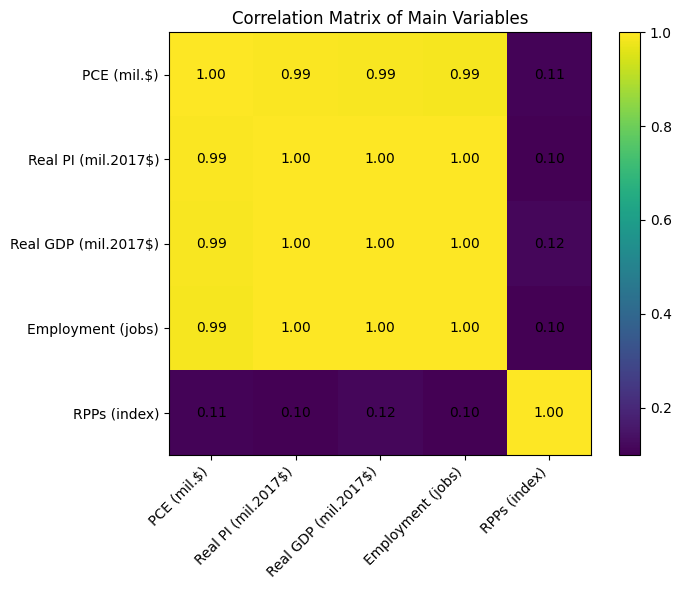

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variables for correlation matrix
corr_vars = [
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)",
    "RPPs (index)"
]

# Correlation matrix
corr = df.reset_index()[corr_vars].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr)

# Axis labels
ax.set_xticks(np.arange(len(corr_vars)))
ax.set_yticks(np.arange(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticklabels(corr_vars)

# Add correlation values inside cells
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

# Title and colorbar
ax.set_title("Correlation Matrix of Main Variables")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

# Save figure for dissertation
plt.savefig("correlation_matrix_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
from scipy import stats
import numpy as np

# FE coefficients
b_FE = results_refined.params

# RE coefficients
b_RE = re_results.params

# Difference in coefficients
b_diff = b_FE - b_RE

# FE covariance matrix
V_FE = results_refined.cov

# RE covariance matrix
V_RE = re_results.cov

# Difference in covariance matrices
V_diff = V_FE - V_RE

# Hausman statistic
hausman_stat = np.dot(
    np.dot(b_diff.T, np.linalg.inv(V_diff)),
    b_diff
)

df_h = len(b_diff)

p_value = 1 - stats.chi2.cdf(hausman_stat, df_h)

print("Hausman Statistic:", hausman_stat)
print("Degrees of Freedom:", df_h)
print("P-value:", p_value)

Hausman Statistic: -38075.15851951715
Degrees of Freedom: 2
P-value: 1.0


In [37]:
print(results_log.params)

log_RPI    0.686668
Name: parameter, dtype: float64


In [38]:
# ==============================
# FE vs RE Model Selection Check
# ==============================

import numpy as np
import pandas as pd
from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects

# Use the same final log specification
df_log = df.copy()
df_log["log_PCE"] = np.log(df_log["PCE (mil.$)"])
df_log["log_RPI"] = np.log(df_log["Real PI (mil.2017$)"])

# Fixed Effects model: entity + time effects
fe_model = PanelOLS.from_formula(
    "log_PCE ~ log_RPI + EntityEffects + TimeEffects",
    data=df_log
)

fe_results = fe_model.fit(cov_type="clustered", cluster_entity=True)

print("\n=== FIXED EFFECTS LOG MODEL ===")
print(fe_results)


# Random Effects model
# Note: RE model does not include EntityEffects/TimeEffects in the same way
re_model = RandomEffects.from_formula(
    "log_PCE ~ log_RPI",
    data=df_log
)

re_results = re_model.fit()

print("\n=== RANDOM EFFECTS LOG MODEL ===")
print(re_results)


# Hausman test using common coefficients
b_fe = fe_results.params
b_re = re_results.params

common_coef = b_fe.index.intersection(b_re.index)

b_diff = b_fe[common_coef] - b_re[common_coef]
v_diff = fe_results.cov.loc[common_coef, common_coef] - re_results.cov.loc[common_coef, common_coef]

# Use pseudo-inverse to avoid singular matrix issues
hausman_stat = float(b_diff.T @ np.linalg.pinv(v_diff) @ b_diff)
df_hausman = len(common_coef)
p_value = 1 - stats.chi2.cdf(hausman_stat, df_hausman)

print("\n=== HAUSMAN TEST ===")
print("Common coefficients:", list(common_coef))
print("Hausman statistic:", hausman_stat)
print("Degrees of freedom:", df_hausman)
print("P-value:", p_value)


# Poolability test is already printed in FE results
print("\n=== POOLABILITY TEST FROM FE MODEL ===")
print("Check the 'F-test for Poolability' in the Fixed Effects output above.")


=== FIXED EFFECTS LOG MODEL ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                log_PCE   R-squared:                        0.7388
Estimator:                   PanelOLS   R-squared (Between):              0.9100
No. Observations:                 884   R-squared (Within):               0.6465
Date:                Thu, Jun 04 2026   R-squared (Overall):              0.9099
Time:                        02:14:52   Log-likelihood                    2275.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2304.9
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(1,815)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):             37

In [53]:
# ============================================================
# FINAL EMPIRICAL ANALYSIS - PANEL DATA
# ============================================================

!pip install linearmodels -q

import pandas as pd
import numpy as np
from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects
from google.colab import drive # Import drive for mounting

# Mount Google Drive for file access
try:
    drive.mount('/content/drive', force_remount=True)
except:
    pass # Drive might already be mounted

# 1. Load data
df = pd.read_excel('/content/drive/MyDrive/PANEL MODELING    DISERTATION /PANEL_DATA_US.xlsx') # Use full path

# 2. Set panel index
df = df.set_index(["STATE", "YEAR"])

# 3. Create log variables
df["log_PCE"] = np.log(df["PCE (mil.$)"])
df["log_RPI"] = np.log(df["Real PI (mil.2017$)"])

# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

desc = df[[
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "RPPs (index)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)"
]].describe()

print("\n=== DESCRIPTIVE STATISTICS ===")
print(desc)

# ============================================================
# CORRELATION MATRIX
# ============================================================

corr = df[[
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)",
    "RPPs (index)"
]].corr()

print("\n=== CORRELATION MATRIX ===")
print(corr)

# ============================================================
# MODEL 1: FULL FIXED EFFECTS MODEL
# ============================================================

model_full = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + Q("Real GDP (mil.2017$)") + Q("Employment (jobs)") + Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results_full = model_full.fit(cov_type="clustered", cluster_entity=True)

print("\n=== MODEL 1: FULL FIXED EFFECTS MODEL ===")
print(results_full)

# ============================================================
# MODEL 2: REFINED FIXED EFFECTS MODEL
# ============================================================

model_refined = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results_refined = model_refined.fit(cov_type="clustered", cluster_entity=True)

print("\n=== MODEL 2: REFINED FIXED EFFECTS MODEL ===")
print(results_refined)

# ============================================================
# MODEL 3: FINAL LOG FIXED EFFECTS MODEL
# ============================================================

model_log_fe = PanelOLS.from_formula(
    "log_PCE ~ log_RPI + EntityEffects + TimeEffects",
    data=df
)

results_log_fe = model_log_fe.fit(cov_type="clustered", cluster_entity=True)

print("\n=== MODEL 3: FINAL LOG FIXED EFFECTS MODEL ===")
print(results_log_fe)

# ============================================================
# MODEL 4: DYNAMIC FIXED EFFECTS MODEL
# ============================================================

df_dyn = df.copy()
df_dyn["lag_PCE"] = df_dyn.groupby(level=0)["PCE (mil.$)"].shift(1)
df_dyn = df_dyn.dropna()

model_dynamic = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ lag_PCE + Q("Real PI (mil.2017$)") + EntityEffects + TimeEffects',
    data=df_dyn
)

results_dynamic = model_dynamic.fit(cov_type="clustered", cluster_entity=True)

print("\n=== MODEL 4: DYNAMIC FIXED EFFECTS MODEL ===")
print(results_dynamic)

# ============================================================
# MODEL 5: PER-WORKER LOG FIXED EFFECTS MODEL
# ============================================================

df_pw = df.copy()
df_pw["PCE_per_worker"] = df_pw["PCE (mil.$)"] / df_pw["Employment (jobs)"]
df_pw["RPI_per_worker"] = df_pw["Real PI (mil.2017$)"] / df_pw["Employment (jobs)"]

df_pw = df_pw.replace([np.inf, -np.inf], np.nan).dropna()

df_pw["log_PCE_per_worker"] = np.log(df_pw["PCE_per_worker"])
df_pw["log_RPI_per_worker"] = np.log(df_pw["RPI_per_worker"])

model_pw = PanelOLS.from_formula(
    "log_PCE_per_worker ~ log_RPI_per_worker + EntityEffects + TimeEffects",
    data=df_pw
)

results_pw = model_pw.fit(cov_type="clustered", cluster_entity=True)

print("\n=== MODEL 5: PER-WORKER LOG FIXED EFFECTS MODEL ===")
print(results_pw)

# ============================================================
# RANDOM EFFECTS LOG MODEL FOR MODEL SELECTION
# ============================================================

model_log_re = RandomEffects.from_formula(
    "log_PCE ~ log_RPI",
    data=df
)

results_log_re = model_log_re.fit()

print("\n=== RANDOM EFFECTS LOG MODEL ===")
print(results_log_re)

# ============================================================
# HAUSMAN TEST: FE VS RE
# ============================================================

b_fe = results_log_fe.params
b_re = results_log_re.params

common_coef = b_fe.index.intersection(b_re.index)

b_diff = b_fe[common_coef] - b_re[common_coef]
v_diff = results_log_fe.cov.loc[common_coef, common_coef] - results_log_re.cov.loc[common_coef, common_coef]

hausman_stat = float(b_diff.T @ np.linalg.pinv(v_diff) @ b_diff)
df_hausman = len(common_coef)
p_value = 1 - stats.chi2.cdf(hausman_stat, df_hausman)

print("\n=== HAUSMAN TEST ===")
print("Common coefficients:", list(common_coef))
print("Hausman statistic:", hausman_stat)
print("Degrees of freedom:", df_hausman)
print("P-value:", p_value)

# ============================================================
# EXPORT CLEAN RESULTS
# ============================================================

desc.to_excel("Table_4_1_Descriptive_Statistics.xlsx")
corr.to_excel("Table_4_2_Correlation_Matrix.xlsx")

with open("Final_Model_Results.txt", "w", encoding="utf-8") as f:
    f.write("=== MODEL 1: FULL FIXED EFFECTS MODEL ===\n")
    f.write(str(results_full))
    f.write("\n\n=== MODEL 2: REFINED FIXED EFFECTS MODEL ===\n")
    f.write(str(results_refined))
    f.write("\n\n=== MODEL 3: FINAL LOG FIXED EFFECTS MODEL ===\n")
    f.write(str(results_log_fe))
    f.write("\n\n=== MODEL 4: DYNAMIC FIXED EFFECTS MODEL ===\n")
    f.write(str(results_dynamic))
    f.write("\n\n=== MODEL 5: PER-WORKER LOG FIXED EFFECTS MODEL ===\n")
    f.write(str(results_pw))
    f.write("\n\n=== RANDOM EFFECTS LOG MODEL ===\n")
    f.write(str(results_log_re))
    f.write("\n\n=== HAUSMAN TEST ===\n")
    f.write(f"Common coefficients: {list(common_coef)}\n")
    f.write(f"Hausman statistic: {hausman_stat}\n")
    f.write(f"Degrees of freedom: {df_hausman}\n")
    f.write(f"P-value: {p_value}\n")

print("\nDONE. Files exported:")
print("- Table_4_1_Descriptive_Statistics.xlsx")
print("- Table_4_2_Correlation_Matrix.xlsx")
print("- Final_Model_Results.txt")

Mounted at /content/drive

=== DESCRIPTIVE STATISTICS ===
        PCE (mil.$)  Real PI (mil.2017$)  RPPs (index)  Real GDP (mil.2017$)  \
count  8.840000e+02         8.840000e+02    884.000000          8.840000e+02   
mean   5.171627e+05         6.360375e+05     97.551459          7.421353e+05   
std    1.887839e+06         2.279228e+06      6.878319          2.666236e+06   
min    1.865320e+04         2.799780e+04     85.018000          2.956570e+04   
25%    6.613625e+04         8.106170e+04     91.873750          9.183402e+04   
50%    1.675598e+05         2.200996e+05     97.053500          2.324788e+05   
75%    3.393250e+05         4.142877e+05    102.363750          4.882802e+05   
max    1.989601e+07         2.013294e+07    114.242000          2.335844e+07   

       Employment (jobs)  
count       8.840000e+02  
mean        7.408213e+06  
std         2.635708e+07  
min         3.850750e+05  
25%         9.205592e+05  
50%         2.533227e+06  
75%         4.871016e+06  
max  

In [40]:
import os

print(os.listdir())

['.config', 'descriptive_statistics.xlsx', 'time_trend_income_consumption.png', 'correlation_matrix_heatmap.png', 'scatter_income_consumption.png', 'correlation_matrix.xlsx', 'panel_model_results.txt', 'model_results.txt', 'selected_states_consumption.png', 'drive', 'sample_data']


In [51]:
import os
print(os.listdir())

['.config', 'descriptive_statistics.xlsx', 'time_trend_income_consumption.png', 'correlation_matrix_heatmap.png', 'scatter_income_consumption.png', 'correlation_matrix.xlsx', 'panel_model_results.txt', 'model_results.txt', 'selected_states_consumption.png', 'drive', 'sample_data']
